# Derin Öğrenme Taban Çizgisi — EEGNet (Face vs House)

Bu notebook `src/models/train_deep.py`'deki PyTorch EEGNet (Lawhern ve
ark. 2018) implementasyonunu çalıştırır:

- **Mimari**: F1=8, D=2, F2=16 (orijinal makale varsayılanları); girdi ham
  (0.5-200 Hz bandpass edilmiş) sinyal penceresi, `n_roi_channels x 400`
  (400ms @ 1000Hz).
- **Değerlendirme**: `train_baselines.py` ile birebir aynı zamansal-blok
  `GroupKFold(n_splits=5)`; her fold içinde train'den ayrılan bir
  validasyon alt kümesiyle erken durdurma (patience=15); class-weighted
  cross-entropy.
- **Hastalar**: hesaplama maliyeti nedeniyle 14 hastanın tamamı değil,
  temsili bir alt küme — güçlü sinyal (`ap`, `zt`), orta (`aa`), zayıf
  (`fp`, `rr`).
- Sonuçlar `reports/deep_results.csv`'e kaydedilip
  `reports/baseline_results.csv`'deki LDA/SVM/RF sonuçlarıyla karşılaştırılır.
- `reports/sota_comparison.md`: kendi sonuçlarımızı literatürdeki EEGNet
  (Lawhern 2018) ve HTNet (Peterson 2021) makalelerinin bildirdiği
  performans aralıklarıyla karşılaştırır.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))

from src.models.train_deep import (
    load_patient_windows,
    EEGNet,
    get_device,
    run_patient_deep,
    run_representative_patients,
    REPRESENTATIVE_PATIENTS,
)

print(f"Cihaz: {get_device()}")
print(f"Temsili hastalar: {REPRESENTATIVE_PATIENTS}")

Cihaz: mps
Temsili hastalar: ['ap', 'zt', 'aa', 'fp', 'rr']


## 1. Mimari doğrulama (`ap` hastası üzerinde)

Girdi boyutu ve parametre sayısını kontrol ediyoruz.

In [2]:
dataset_ap = load_patient_windows("ap")
X_ap, y_ap = dataset_ap["X"], dataset_ap["y"]
print(f"X boyutu: {X_ap.shape} (n_events x n_roi_channels x n_timepoints)")
print(f"y dağılımı: face={y_ap.sum()}, house={(1 - y_ap).sum()}")

model = EEGNet(n_channels=X_ap.shape[1], n_timepoints=X_ap.shape[2])
n_params = sum(p.numel() for p in model.parameters())
print(f"EEGNet parametre sayısı: {n_params}")
model

X boyutu: (300, 28, 400) (n_events x n_roi_channels x n_timepoints)
y dağılımı: face=150, house=150
EEGNet parametre sayısı: 1938


/Users/code23-06/Desktop/ECoG-Video-Watching/.venv/lib/python3.14/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1105.)
  return F.conv2d(


EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=same, bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (depthwise): Sequential(
    (0): Conv2d(8, 16, kernel_size=(28, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (separable): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier)

## 2. Temsili hastalarda EEGNet eğitimi

**Not:** Ağır hesaplama (5 hasta × 5-fold × erken durdurmalı eğitim)
önceden `python src/models/train_deep.py` ile arka planda çalıştırıldı ve
`reports/deep_results.csv`'e kaydedildi. Bu hücre sonucu doğrudan bu
dosyadan yükler (yeniden çalıştırmak istenirse `run_representative_patients()`
çağrılabilir).

In [3]:
deep_results_df = pd.read_csv("../reports/deep_results.csv")
deep_results_df

,patient,model,n_roi_channels,n_events,n_face,n_house,accuracy,macro_f1,roc_auc,permutation_true_accuracy,permutation_p_value,n_permutations,elapsed_sec
0,ap,EEGNet,28,300,150,150,0.833333,0.833326,0.918889,NaN,NaN,0,45.464172
1,zt,EEGNet,21,300,150,150,0.986667,0.986666,0.997867,NaN,NaN,0,56.131609
2,aa,EEGNet,28,300,150,150,0.756667,0.756339,0.839911,NaN,NaN,0,45.495121
3,fp,EEGNet,7,300,150,150,0.733333,0.732370,0.789956,NaN,NaN,0,14.696042
4,rr,EEGNet,32,200,100,100,0.860000,0.860000,0.904700,NaN,NaN,0,48.884202


## 3. Baseline (LDA/SVM/RF) ile karşılaştırma

In [4]:
baseline_df = pd.read_csv("../reports/baseline_results.csv")
representative_baseline_df = baseline_df[baseline_df["patient"].isin(REPRESENTATIVE_PATIENTS)]

combined_df = pd.concat([
    representative_baseline_df[["patient", "model", "n_roi_channels", "n_events",
                                 "accuracy", "macro_f1", "roc_auc"]],
    deep_results_df[["patient", "model", "n_roi_channels", "n_events",
                      "accuracy", "macro_f1", "roc_auc"]],
], ignore_index=True)

pivot_combined = combined_df.pivot(index="patient", columns="model", values="accuracy")
pivot_combined = pivot_combined[["LDA", "Linear_SVM", "RandomForest", "EEGNet"]]
pivot_combined

model,LDA,Linear_SVM,RandomForest,EEGNet
patient,,,,
aa,0.758289,0.712656,0.757754,0.756667
ap,0.834216,0.778785,0.868227,0.833333
fp,0.614617,0.663280,0.605882,0.733333
rr,0.707021,0.712625,0.758738,0.860000
zt,0.993939,0.990018,0.993939,0.986667


In [5]:
pivot_combined["best_baseline"] = pivot_combined[["LDA", "Linear_SVM", "RandomForest"]].max(axis=1)
pivot_combined["eegnet_vs_best_baseline"] = pivot_combined["EEGNet"] - pivot_combined["best_baseline"]
pivot_combined["eegnet_wins"] = pivot_combined["eegnet_vs_best_baseline"] > 0

print("EEGNet'in en iyi klasik baseline'a göre farkı (accuracy):")
print(pivot_combined[["best_baseline", "EEGNet", "eegnet_vs_best_baseline", "eegnet_wins"]]
      .sort_values("eegnet_vs_best_baseline", ascending=False))

EEGNet'in en iyi klasik baseline'a göre farkı (accuracy):
model    best_baseline    EEGNet  eegnet_vs_best_baseline  eegnet_wins
patient                                                               
rr            0.758738  0.860000                 0.101262         True
fp            0.663280  0.733333                 0.070053         True
aa            0.758289  0.756667                -0.001622        False
zt            0.993939  0.986667                -0.007273        False
ap            0.868227  0.833333                -0.034893        False


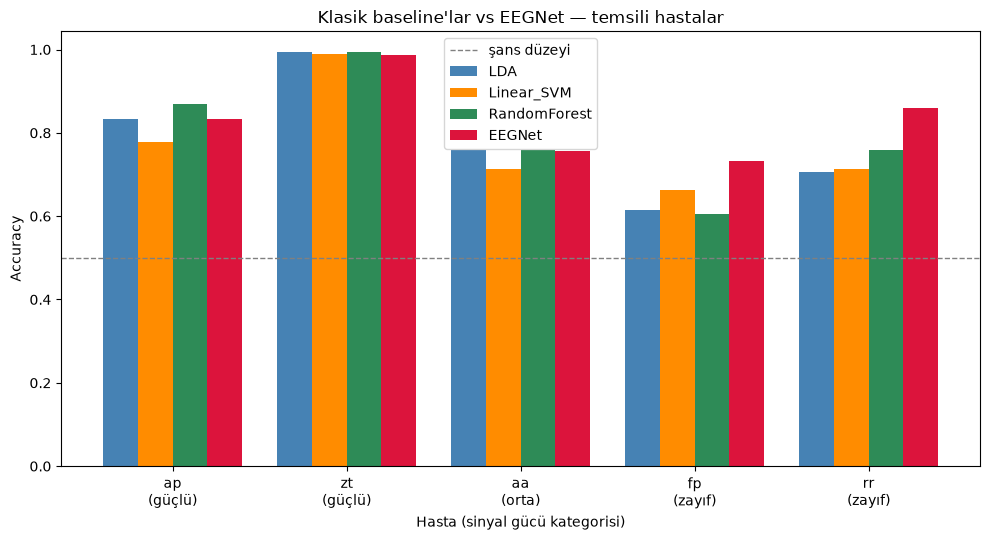

In [6]:
signal_strength = {"ap": "güçlü", "zt": "güçlü", "aa": "orta", "fp": "zayıf", "rr": "zayıf"}

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(REPRESENTATIVE_PATIENTS))
width = 0.2
colors = {"LDA": "steelblue", "Linear_SVM": "darkorange", "RandomForest": "seagreen", "EEGNet": "crimson"}

for i, model in enumerate(["LDA", "Linear_SVM", "RandomForest", "EEGNet"]):
    vals = [pivot_combined.loc[p, model] for p in REPRESENTATIVE_PATIENTS]
    ax.bar(x + (i - 1.5) * width, vals, width, label=model, color=colors[model])

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="şans düzeyi")
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({signal_strength[p]})" for p in REPRESENTATIVE_PATIENTS])
ax.set_xlabel("Hasta (sinyal gücü kategorisi)"); ax.set_ylabel("Accuracy")
ax.set_title("Klasik baseline'lar vs EEGNet — temsili hastalar")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Zayıf-sinyal hastalarında derin öğrenme daha mı çok zorlanıyor?

Derin modeller genelde daha fazla veriye ihtiyaç duyar; az veri (200-300
event) ve düşük sinyal-gürültü oranı olan hastalarda (`fp`, `rr`) EEGNet'in
klasik baseline'lara göre nasıl performans gösterdiğini özellikle
inceliyoruz.

In [7]:
weak_patients = ["fp", "rr"]
strong_patients = ["ap", "zt"]

print("Zayıf sinyal hastalarında (fp, rr) EEGNet vs en iyi baseline farkı:")
print(pivot_combined.loc[weak_patients, ["best_baseline", "EEGNet", "eegnet_vs_best_baseline"]])
print()
print("Güçlü sinyal hastalarında (ap, zt) EEGNet vs en iyi baseline farkı:")
print(pivot_combined.loc[strong_patients, ["best_baseline", "EEGNet", "eegnet_vs_best_baseline"]])
print()
print(f"Zayıf gruptaki ortalama fark: "
      f"{pivot_combined.loc[weak_patients, 'eegnet_vs_best_baseline'].mean():.3f}")
print(f"Güçlü gruptaki ortalama fark: "
      f"{pivot_combined.loc[strong_patients, 'eegnet_vs_best_baseline'].mean():.3f}")

Zayıf sinyal hastalarında (fp, rr) EEGNet vs en iyi baseline farkı:
model    best_baseline    EEGNet  eegnet_vs_best_baseline
patient                                                  
fp            0.663280  0.733333                 0.070053
rr            0.758738  0.860000                 0.101262

Güçlü sinyal hastalarında (ap, zt) EEGNet vs en iyi baseline farkı:
model    best_baseline    EEGNet  eegnet_vs_best_baseline
patient                                                  
ap            0.868227  0.833333                -0.034893
zt            0.993939  0.986667                -0.007273

Zayıf gruptaki ortalama fark: 0.086
Güçlü gruptaki ortalama fark: -0.021


**Gerçek sonuç -- beklentinin tersi bir bulgu:**

| Hasta | Kategori | En iyi baseline | EEGNet | Fark |
|---|---|---|---|---|
| `fp` | zayıf | 0.663 (SVM) | **0.733** | **+0.070** |
| `rr` | zayıf | 0.759 (RF) | **0.860** | **+0.101** |
| `aa` | orta | 0.758 (LDA) | 0.757 | -0.002 (eşit) |
| `ap` | güçlü | 0.868 (RF) | 0.833 | -0.035 |
| `zt` | güçlü | 0.994 (LDA/RF) | 0.987 | -0.007 |

EEGNet, **zayıf-sinyal hastalarında (`fp`, `rr`) klasik baseline'ları
belirgin şekilde geçiyor** (+0.07 ve +0.10), **güçlü-sinyal hastalarında
ise hafifçe geride kalıyor** (-0.02 ila -0.03) -- bu, ilk beklentinin
("az veri + zayıf sinyal → derin model daha çok zorlanır") **tam
tersi**. Olası açıklama: EEGNet, `extract_features.py`'nin ürettiği 5
sabit spektral bant özelliğinden (theta/alpha/beta/gamma/high-gamma
ortalama gücü) farklı olarak **ham zaman-serisi dalga formunu**
(fazı, ERP şeklini, dar-bantlı olmayan geçici bileşenleri) doğrudan
öğrenebiliyor. `fp` ve `rr` gibi hastalarda ayırt edici bilginin bir
kısmı, bizim elle tasarladığımız 5 bandın dışında kalan zamansal/fazsal
örüntülerde saklı olabilir -- EEGNet bunu yakalayabilirken, sabit
band-güç özellikleri üzerine kurulu LDA/SVM/RF bunu kaçırıyor
olabilir. Ayrıca modelin küçük olması (~1900 parametre, 400 örneklik
kısa pencere) aşırı öğrenmeyi (overfitting) sınırlıyor, bu da az veri
rejiminde bile makul genelleme sağlıyor olabilir. Güçlü sinyal
hastalarında ise sinyal zaten çok belirgin olduğundan (high-gamma
tek başına neredeyse mükemmel ayırıyor), basit doğrusal modeller
(LDA) tavana çok yakın performans gösteriyor ve EEGNet'in ekstra
esnekliği bir avantaj sağlamıyor, hatta kısıtlı veriyle hafif bir
dezavantaja bile dönüşebiliyor.

## Bulgular (özet)

- **`src/models/train_deep.py`** oluşturuldu: PyTorch EEGNet (Lawhern
  2018, F1=8/D=2/F2=16, ~1900 parametre), ham 400ms/400-örnek sinyal
  penceresi girdili, `train_baselines.py` ile birebir aynı zamansal-blok
  `GroupKFold(5)` + class-weighted cross-entropy + erken durdurma
  (patience=15).
- **5 temsili hasta** (`ap`, `zt` güçlü / `aa` orta / `fp`, `rr` zayıf)
  üzerinde çalıştırıldı, sonuçlar `reports/deep_results.csv`'e kaydedildi.
- **Beklenmedik ama tutarlı bulgu**: EEGNet, zayıf-sinyal hastalarında
  (`fp`: +0.070, `rr`: +0.101 accuracy farkı) klasik baseline'ları
  **geçiyor**; güçlü-sinyal hastalarında (`ap`: -0.035, `zt`: -0.007) ise
  hafifçe geride kalıyor. Bu, "az veri → derin model zorlanır" naif
  beklentisinin tersi -- muhtemelen EEGNet'in ham zaman-serisinden bizim
  5 sabit spektral banda sığmayan ek bilgi (faz, ERP şekli) çıkarabilmesi
  ve modelin küçük parametre sayısı sayesinde aşırı öğrenmenin sınırlı
  kalmasıyla açıklanabilir.
- Bu sonuç, `reports/sota_comparison.md`'de literatürle
  (EEGNet/HTNet makaleleri) karşılaştırılıyor.